In [ ]:
%pip install tqdm
%pip install wandb --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 6.0 MB/s eta 0:00:00


In [ ]:
import wandb
import os
import torch
from PIL import Image
from torchvision import transforms
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm
from torch.utils.data import DataLoader
import numpy as np
import torchvision.datasets as datasets
from scipy.stats import gaussian_kde
from scipy.stats import norm
from random import randint
import torch.distributions as dist
import math

In [ ]:
wandb.login(key='')

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
sweep_config = {
    'method': 'random'
    }

metric = {
    'name':'loss',
    'goal':'minimize'
}
sweep_config['metric']=metric

parameters_dict = {
    'latent_dim': {
        'value':10},
    'num_epochs':{
        'value':20},
    'batch_size':{
        'value':16},
    'learning_rate':{
        'value':1e-4
        },
    }

sweep_config['parameters'] = parameters_dict

In [ ]:
sweep_id = wandb.sweep(sweep_config, project='conv planes')
project='conv planes'
folder_path=f"/content/drive/MyDrive/Colab Notebooks/FYP/Sweeps/{project}/{sweep_id}"
os.makedirs(folder_path)

Create sweep with ID: raudri0r
Sweep URL: https://wandb.ai/t-a-emm-20/conv%20planes/sweeps/raudri0r


torch.Size([17744, 1, 100, 100])
torch.Size([14195, 1, 100, 100])


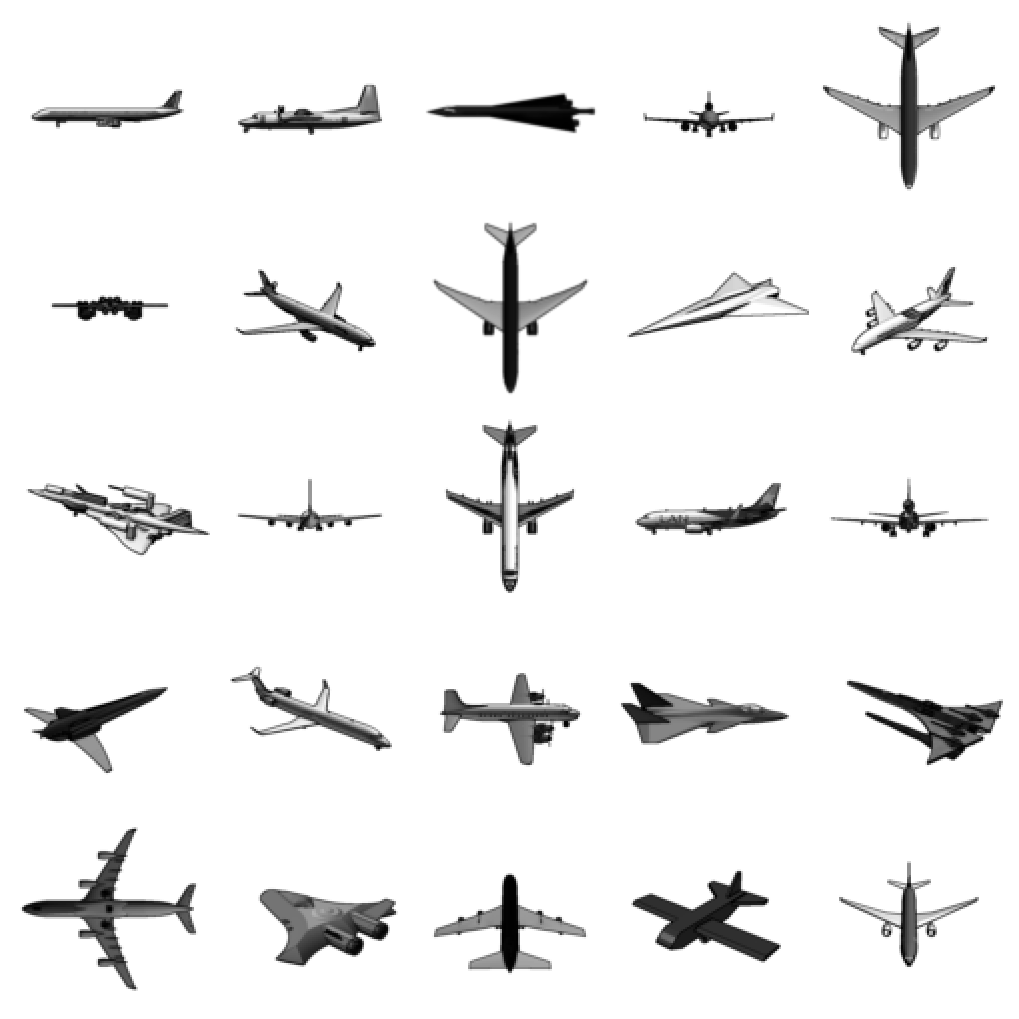

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

folder='/content/drive/MyDrive/Colab Notebooks/FYP/Data/ShapeNet Images'
transform=transforms.Compose([
          transforms.Resize((100, 100)),
          transforms.ToTensor(),])
images=[]

for filename in os.listdir(folder):
    if filename.endswith('.png'):
        path=os.path.join(folder,filename)
        img=Image.open(path)
        greyimg=img.convert('L')
        tensors=transform(greyimg)
        images.append(tensors)

random.seed(42)
random.shuffle(images)
images=torch.stack(images)
splitratio=0.80
split=int(len(images)*splitratio)
print(images.shape)

train_dataset=images[:split]
eval_dataset=images[split:]

train_dataset=train_dataset.reshape(-1,1,100,100)/255
eval_dataset=eval_dataset.reshape(-1,1,100,100)/255
print(train_dataset.shape)

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(train_dataset[i*5 +j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

In [ ]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
      super().__init__()
      #encoding
      self.conv_1=nn.Conv2d(1,32,14,2, padding=1)
      self.conv_2=nn.Conv2d(32,64,10,2, padding=1)
      self.conv_3=nn.Conv2d(64,128,4,2, padding=1)
      self.conv_4=nn.Conv2d(128,256,2,2, padding=1)
      self.mu=nn.Linear(6400,latent_dim)
      self.logstd=nn.Linear(6400,latent_dim)

      self.bn_1=nn.BatchNorm2d(32)
      self.bn_2=nn.BatchNorm2d(64)
      self.bn_3=nn.BatchNorm2d(128)
      self.bn_4=nn.BatchNorm2d(256)

      #deocoding
      self.fc_1=nn.Linear(latent_dim,2500)
      self.fc_2=nn.Linear(2500, 7500)
      self.fc_3=nn.Linear(7500, 15000)
      self.fc_4=nn.Linear(15000, 10000)


    def encode(self,x):
        n=x.shape[0]
        x=F.relu(self.bn_1(self.conv_1(x)))
        x=F.relu(self.bn_2(self.conv_2(x)))
        x=F.relu(self.bn_3(self.conv_3(x)))
        x=F.relu(self.bn_4(self.conv_4(x)))
        x=x.reshape(n,6400)
        mu=self.mu(x)
        logstd=self.logstd(x)

        return mu, logstd

    def decode(self, z):
        z=F.relu(self.fc_1(z))
        z=F.relu(self.fc_2(z))
        z=F.relu(self.fc_3(z))
        x_recon=torch.sigmoid(self.fc_4(z))

        return x_recon


    def forward(self,x):
        mu, logstd = self.encode(x)
        std=torch.exp(0.5*logstd)
        eps = torch.randn_like(logstd)
        z_reparam = mu + std*eps
        z_prior = torch.randn_like(logstd)
        x_recon = self.decode(z_reparam)

        return x_recon, mu, logstd, z_prior, z_reparam

In [ ]:
def loss_function(x, x_recon, mu, logstd, n, latent_dim, kernel_bandwidth, scales, z_reparam, z_prior):
    recon_loss=F.mse_loss(x_recon.reshape(x.shape[0],-1),x.reshape(x.shape[0],-1),reduction='sum')
    kl_div = -0.5*torch.sum(1+logstd-mu.pow(2)-(torch.exp(logstd)).pow(2))

    def imq_kernel(z1,z2):
        Cbase = (2* latent_dim * kernel_bandwidth**2)
        k =0
        for scale in scales:
            C=scale*Cbase

            k+= C/(C + torch.norm(z1.unsqueeze(1)-z2.unsqueeze(0),dim=-1) ** 2)
        return k

    k_z=imq_kernel(z_reparam,z_reparam)
    k_z_prior=imq_kernel(z_prior,z_prior)
    k_cross=imq_kernel(z_reparam,z_prior)

    mmd_z=(k_z - k_z.diag().diag()).sum()/((n-1)*n)
    mmd_z_prior=(k_z_prior-k_z_prior.diag().diag()).sum()/((n-1)*n)
    mmd_cross=k_cross.sum()/(n**2)
    mmd_loss=mmd_z+mmd_z_prior-2*mmd_cross

    return recon_loss, kl_div, mmd_loss

In [ ]:
def fitness_func(alpha, lbd, recon_loss, kl_div, mmd_loss, loss):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    loss_new = recon_loss + (1-alpha)*kl_div + (alpha + lbd -1)*mmd_loss
    fitness=1/loss_new

    return fitness.to(device)

In [ ]:
def selfadapt_SBX(pop_size, mutation_rate, eta_alpha, eta_lbd, crossover_rate, alpha_tprev, lbd_tprev, recon_loss, kl_div, mmd_loss, loss):
    pop=[(dist.Normal(alpha_tprev,0.05).sample(), dist.Normal(lbd_tprev,2).sample()) for n in range(pop_size)]
    fit_scores=[fitness_func(alpha_t,lbd_t, recon_loss, kl_div, mmd_loss, loss) for alpha_t, lbd_t in pop]
    sorted_ind=sorted(range(len(fit_scores)), key=lambda i: fit_scores[i], reverse=True)
    sorted_pop=[pop[i] for i in sorted_ind]
    fit_probs=torch.softmax(torch.tensor(fit_scores), dim=0)
    new_pop=[]

    for i in range(pop_size):
        prt=torch.rand(1)
        parent1 = torch.multinomial(fit_probs.clone().detach(),1, replacement=False)
        alpha_t1, lbd_t1=sorted_pop[parent1]
        #alpha_t2, lbd_t2=sorted_pop[parent2]

        if prt<crossover_rate:
            u=torch.rand(1).to(device)
            if u <= 0.5:
                rcalpha=(2*u)**(1/(eta_alpha + 1))
                rclbd=(2*u)**(1/(eta_lbd + 1))
            else:
                rcalpha=(1/(2*(1-u)))**(1/(eta_alpha + 1))
                rclbd=(1/(2*(1-u)))**(1/(eta_lbd + 1))
            cpop=[]
            alpha1=0.5*((1 + rcalpha)*alpha_t1 + (1 - rcalpha)*alpha_tprev)
            lbd1=0.5*((1 + rclbd)*lbd_t1 + (1 - rclbd)*lbd_tprev)
            cpop.append((alpha1,lbd1))

            alpha2=0.5*((1 - rcalpha)*alpha_t1 + (1 + rcalpha)*alpha_tprev)
            lbd2=0.5*((1 - rclbd)*lbd_t1 + (1 + rclbd)*lbd_tprev)
            cpop.append((alpha2,lbd2))

            cfit_scores=[fitness_func(alpha_tplus1, lbd_tplus1, recon_loss, kl_div, mmd_loss, loss) for alpha_tplus1, lbd_tplus1 in cpop]
            sorted_scores= sorted(range(len(cfit_scores)), key=lambda i: cfit_scores[i], reverse=True)
            sorted_cpop=[cpop[i] for i in sorted_scores]

            alpha_tplus1, lbd_tplus1 = sorted_cpop[0]

            gamma_alpha = 1.1
            beta_alpha=abs(1 + 2*((alpha_tplus1-alpha_tprev)/(alpha_tprev-alpha_t1)))
            gamma_lbd = 1.5
            beta_lbd=abs(1 + 2*((lbd_tplus1-lbd_tprev)/(lbd_tprev-lbd_t1)))

            parent1_fit=fitness_func(alpha_t1, lbd_t1, recon_loss, kl_div, mmd_loss, loss)
            parent2_fit=fitness_func(alpha_tprev, lbd_tprev, recon_loss, kl_div, mmd_loss, loss)
            child_fit=fitness_func(alpha_tplus1, lbd_tplus1, recon_loss, kl_div, mmd_loss, loss)

            if alpha_t1 > alpha_tprev:
                if alpha_tplus1 < alpha_tprev:
                    if child_fit > parent2_fit:
                        eta_alpha_dash = -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + gamma_alpha*(beta_alpha - 1)))
                    else:
                        eta_alpha_dash = -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + (1/gamma_alpha)*(beta_alpha -1)))

                elif alpha_tplus1 > alpha_t1:
                    if child_fit > parent1_fit:
                        eta_alpha_dash= -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + gamma_alpha*(beta_alpha - 1)))
                    else:
                        eta_alpha_dash = -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + (1/gamma_alpha)*(beta_alpha -1)))

                else:
                    if child_fit > parent1_fit or child_fit > parent2_fit:
                        eta_alpha_dash= ((1 + eta_alpha)/gamma_alpha)-1
                    else:
                        eta_alpha_dash= gamma_alpha*(1 + eta_alpha)-1

            else:
                if alpha_tplus1 < alpha_t1:
                    if child_fit > parent1_fit:
                        eta_alpha_dash= -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + gamma_alpha*(beta_alpha - 1)))
                    else:
                        eta_alpha_dash = -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + (1/gamma_alpha)*(beta_alpha -1)))

                elif alpha_tplus1 > alpha_tprev:
                      if child_fit > parent2_fit:
                          eta_alpha_dash= -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + gamma_alpha*(beta_alpha - 1)))
                      else:
                          eta_alpha_dash = -1 + ((eta_alpha + 1)*math.log(beta_alpha))/(math.log(1 + (1/gamma_alpha)*(beta_alpha -1)))

                else:
                    if child_fit > parent1_fit or child_fit > parent2_fit:
                        eta_alpha_dash= ((1 + eta_alpha)/gamma_alpha) - 1
                    else:
                        eta_alpha_dash= gamma_alpha*(1 + eta_alpha) - 1

            if lbd_t1 > lbd_tprev:
                if lbd_tplus1 < lbd_tprev:
                    if child_fit > parent2_fit:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + gamma_lbd*(beta_lbd - 1)))
                    else:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + (1/gamma_lbd)*(beta_lbd - 1)))

                elif lbd_tplus1 > lbd_t1:
                    if child_fit > parent1_fit:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + gamma_lbd*(beta_lbd - 1)))
                    else:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + (1/gamma_lbd)*(beta_lbd - 1)))

                else:
                    if child_fit > parent1_fit or child_fit > parent2_fit:
                        eta_lbd_dash= ((1 + eta_lbd)/gamma_lbd) - 1
                    else:
                        eta_lbd_dash= gamma_lbd*(1 + eta_lbd) - 1

            else:
                if lbd_tplus1 < lbd_t1:
                    if child_fit > parent1_fit:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + gamma_lbd*(beta_lbd - 1)))
                    else:
                        eta_lbd_dash = -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + (1/gamma_lbd)*(beta_lbd -1)))

                elif lbd_tplus1 > lbd_tprev:
                    if child_fit > parent2_fit:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + gamma_lbd*(beta_lbd - 1)))
                    else:
                        eta_lbd_dash= -1 + ((eta_lbd + 1)*math.log(beta_lbd))/(math.log(1 + (1/gamma_lbd)*(beta_lbd - 1)))

                else:
                    if child_fit > parent1_fit or child_fit > parent2_fit:
                        eta_lbd_dash = ((1 + eta_lbd)/gamma_lbd) - 1
                    else:
                        eta_lbd_dash = gamma_lbd*(1 + eta_lbd) - 1

            if eta_alpha_dash < 0:
                eta_alpha_dash=0

            if eta_alpha_dash > 50:
                eta_alpha_dash = 50

            if eta_lbd_dash < 0:
                eta_lbd_dash = 0

            if eta_lbd_dash > 50:
                eta_alpha_dash = 50

            if prt<mutation_rate:
                m=torch.tensor(random.uniform(-4,4)).to(device)
                rm=(1/6)*((1/math.pi)*(1/(1+m**2)))
                alpha_tplus1= alpha_tplus1 + rm
                l=torch.tensor(random.uniform(-4,4)).to(device)
                rm=((1/math.pi)*(1/(1+l**2)))
                lbd_tplus1= lbd_tplus1 + rm
                new_pop.append((alpha_tplus1, lbd_tplus1, eta_alpha_dash, eta_lbd_dash))

            else:
                new_pop.append((alpha_tplus1, lbd_tplus1, eta_alpha_dash, eta_lbd_dash))


        elif prt<mutation_rate:
            m=torch.tensor(random.uniform(-4,4)).to(device)
            rm=(1/6)*((1/math.pi)*(1/(1+m**2)))
            alpha_tplus1= alpha_t1 + rm
            l=torch.tensor(random.uniform(-4,4)).to(device)
            rm=((1/math.pi)*(1/(1+l**2)))
            lbd_tplus1= lbd_t1 + rm
            new_pop.append((alpha_tplus1, lbd_tplus1, eta_alpha, eta_lbd))

        else:
            k=torch.randint(0, len(sorted_pop), (1,))
            alpha_tplus1, lbd_tplus1 = sorted_pop[k]
            new_pop.append((alpha_tplus1, lbd_tplus1, eta_alpha, eta_lbd))


    final_pop=[]
    for i in range(len(new_pop)):
      alpha_tplus1, lbd_tplus1, eta_alpha, eta_lbd = new_pop[i]

      if (1-alpha_tplus1)*kl_div > 0:
          final_pop.append((alpha_tplus1, lbd_tplus1, eta_alpha, eta_lbd))

    post_fit=[fitness_func(alpha_tplus1,lbd_tplus1, recon_loss, kl_div, mmd_loss, loss) for alpha_tplus1, lbd_tplus1, eta_alpha, eta_lbd in final_pop]
    post_fit_probs=torch.softmax(torch.tensor(post_fit), dim=0)
    child = torch.multinomial(post_fit_probs.clone().detach(),1, replacement=True)

    alpha_star, lbd_star, eta_alpha_dash, eta_lbd_dash = max(final_pop, key=lambda ind: fitness_func(ind[0], ind[1], recon_loss, kl_div, mmd_loss, loss))

    return alpha_star, lbd_star, eta_alpha_dash, eta_lbd_dash

In [ ]:
def train(config=None):
    wandb.init(config = config)
    config=wandb.config

    input_dim=10000
    latent_dim=config.latent_dim
    num_epochs=config.num_epochs
    batch_size=config.batch_size
    learning_rate=config.learning_rate
    alpha=torch.tensor(random.uniform(-0.4,0.4)).to(device)
    lbd=lbd=random.uniform(50,200)
    scales = [0.1, 0.2, 0.5, 1.0, 2.0, 5, 10.0]
    kernel_bandwidth=1

    pop_size=12
    num_gen=2
    eta_alpha=8
    eta_lbd=3
    mutation_rate=0.2
    crossover_rate=0.3

    #dataset
    train_loader=DataLoader(dataset=train_dataset, batch_size=batch_size)
    eval_loader=DataLoader(dataset=eval_dataset, batch_size=batch_size)
    model=VariationalAutoEncoder(input_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    z_star=[]

    #train
    for epoch in range(num_epochs):
        loop = tqdm(enumerate(train_loader), total=len(train_loader), desc='Training')
        total_loss=0
        eval_total_loss=0

        for i, x in loop:
            x=x.to(device).view(x.shape[0],1,100,100)
            x_recon, mu, logstd, z_prior, z_reparam =model(x)
            #print(x_recon.shape)
            n=z_reparam.shape[0]
            z_star.append(z_reparam.detach())

            recon_loss, kl_div, mmd_loss=loss_function(x, x_recon, mu, logstd, n, latent_dim, kernel_bandwidth, scales, z_reparam, z_prior)
            loss= recon_loss + (1-alpha)*kl_div + (alpha + lbd -1)*mmd_loss
            total_loss += loss.item()

            #backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loop.set_postfix(loss=loss.item())

            wandb.log({'loss':loss,'epoch':epoch,'recon loss':recon_loss,'kl diverg':kl_div,'mmd loss':mmd_loss})

        alpha_star, lbd_star, eta_alpha_dash, eta_lbd_dash= selfadapt_SBX(pop_size, mutation_rate, eta_alpha, eta_lbd, crossover_rate, alpha, lbd, recon_loss, kl_div, mmd_loss, loss)
        alpha=alpha_star
        lbd=lbd_star
        eta_alpha=eta_alpha_dash
        eta_lbd=eta_lbd_dash
        wandb.log({'alpha':alpha, 'lbd':lbd, 'eta_alpha':eta_alpha, 'eta_lbd':eta_lbd})

        avg_loss=total_loss/(len(train_loader))
        wandb.log({'average epoch training loss':avg_loss})

        with torch.no_grad():
            loop2 = tqdm(enumerate(eval_loader), total=len(eval_loader), desc="Evaluation")
            for i, y in loop2:
                y = y.to(device).view(y.shape[0], 1, 100, 100)
                y_recon, mu_eval, logstd_eval, z_prior_eval, z_reparam_eval = model(y)
                n = z_reparam.shape[0]

                recon_loss_eval, kl_div_eval, mmd_eval = loss_function(y, y_recon, mu_eval, logstd_eval, n, latent_dim, kernel_bandwidth, scales, z_reparam_eval, z_prior_eval)
                eval_loss = recon_loss_eval + (1-alpha)*kl_div_eval +(alpha + lbd -1)*mmd_eval
                eval_total_loss += eval_loss.item()

                loop2.set_postfix(eval_loss=eval_loss.item())
                wandb.log({'eval_loss':eval_loss,'epoch':epoch})


            avg_eval_loss= eval_total_loss/ (len(eval_loader))
            wandb.log({'average epoch evaluation loss':avg_eval_loss})

    run_name=wandb.run.name
    #Sample
    gen_imgs=[]
    num_samples=25
    full_batch_nbr=int(num_samples/batch_size)
    last_batch_nbr=num_samples % batch_size

    for i in range(num_samples):
        z_gen=torch.zeros(10)
        for j in range(latent_dim):
            z_gen[j]=torch.tensor(np.random.normal(loc=0, scale=1, size=1))
        #print(z_gen)
        z_gen=z_gen.to(device)
        x_gen=model.decode(z_gen).detach()
        gen_img=x_gen.reshape(1,100,100)
        gen_imgs.append(gen_img)
    gen_imgs=torch.stack(gen_imgs)


    #Plot
    fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

    for i in range(5):
        for j in range(5):
            axes[i][j].imshow(gen_imgs[i*5 +j].cpu().squeeze(0), cmap='gray')
            axes[i][j].axis('off')
    plt.tight_layout(pad=0.)

    run_name=wandb.run.name
    run_gen='generated'
    run_gen_name=run_name+run_gen
    img_path=f"/content/drive/MyDrive/Colab Notebooks/FYP/Sweeps/{project}/{sweep_id}/{run_gen_name}.png"
    plt.savefig(img_path)


    #Reconstruction
    to_recon=[]
    hi=[0,3,4,6,9,20,24,18,17,11]
    for i in range(10):
        to_recon.append(train_dataset[hi[i]])

    to_recon_imgs=torch.stack(to_recon)

    recond=[]
    rec_errors=[]
    for i in range(10):
        x=to_recon_imgs[i].to(device).view(1,1,100,100)
        x_recon, mu, logstd, z_prior, z_reparam =model(x)
        #print(x_recon.shape)
        for i in range(input_dim):
            pixel=x_recon[0,i]
            #print(pixel)
            if pixel >=0.85:
              pixel=1
            x_recon[0,i]=pixel
        recon_error=F.mse_loss(x_recon.reshape(x.shape[0],-1),x.reshape(x.shape[0],-1),reduction='mean')
        x_recon_img=x_recon.reshape(1,100,100)
        recond.append(x_recon_img.detach())
        rec_errors.append(recon_error.detach())

    recond_imgs=torch.stack(recond)
    print(rec_errors)

    fig3, axes3 = plt.subplots(nrows=2, ncols=10, figsize=(10,2))
    for i in range(10):
        axes3[0][i].imshow(to_recon_imgs[i].cpu().squeeze(0), cmap='gray')
        axes3[0][i].axis('off')
        axes3[1][i].imshow(recond_imgs[i].cpu().squeeze(0), cmap='gray')
        axes3[1][i].axis('off')

    plt.tight_layout(pad=0.)
    run_recon='recon'
    run_recon_name=run_name+run_recon
    img_path=f"/content/drive/MyDrive/Colab Notebooks/FYP/Sweeps/{project}/{sweep_id}/{run_recon_name}.png"
    plt.savefig(img_path)

In [ ]:
wandb.agent(sweep_id, train, count=1)

wandb: Agent Starting Run: 9iassw2g with config:
wandb: 	batch_size: 16
wandb: 	latent_dim: 10
wandb: 	learning_rate: 0.0001
wandb: 	num_epochs: 20
wandb: Currently logged in as: t-a-emm-20. Use `wandb login --relogin` to force relogin


Training: 100%|██████████| 1109/1109 [02:11<00:00,  8.40it/s, loss=-0.671]


epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kl diverg,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mmd loss,█▆▂▁▁▁▂▂▁▁▁▁▂▂▁▃▂▁▁▂▁▁▂▁▁▂▂▁▂▂▁▂▁▂▂▂▂▁▁▁
recon loss,▆▄▃▇▇▃█▅▃▄▆▆▄▆▇▄▂▂▅▅▆▇▁▅▅▅▇▄▅▄▇▇▆▆▄▇▆▅▅▇
epoch,0
kl diverg,-9.14054
loss,-0.67058
mmd loss,0.0568
recon loss,2.25599


Run 9iassw2g errored:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/wandb/agents/pyagent.py", line 307, in _run_job
    self._function()
  File "<ipython-input-11-363734395574>", line 55, in train
    alpha_star, lbd_star, eta_alpha_dash, eta_lbd_dash= selfadapt_SBX(pop_size, mutation_rate, eta_alpha, eta_lbd, crossover_rate, alpha, lbd, recon_loss, kl_div, mmd_loss, loss)
  File "<ipython-input-10-059c1d2f64c3>", line 172, in selfadapt_SBX
    child = torch.multinomial(post_fit_probs.clone().detach(),1, replacement=False)
RuntimeError: cannot sample n_sample > prob_dist.size(-1) samples without replacement

wandb: ERROR Run 9iassw2g errored:
wandb: ERROR Traceback (most recent call last):
wandb: ERROR   File "/usr/local/lib/python3.10/dist-packages/wandb/agents/pyagent.py", line 307, in _run_job
wandb: ERROR     self._function()
wandb: ERROR   File "<ipython-input-11-363734395574>", line 55, in train
wandb: ERROR     alpha_star, lbd_star, eta_alpha